In [12]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
from src.data_loader import load_twins_data
from src.preprocessing import preprocess
from dowhy import CausalModel

df = load_twins_data()
df = df.dropna(subset=['tobacco', 'alcohol']).reset_index(drop=True)
df['any_exposure'] = ((df['tobacco'] == 1) | (df['alcohol'] == 1)).astype(int)

X, T, Y, exposure, pair_id = preprocess(df)

# Assemble a single DataFrame for DoWhy
dowhy_df = X.copy()
dowhy_df['treatment'] = np.asarray(T)
dowhy_df['outcome'] = np.asarray(Y)

covariate_names = list(X.columns)

print(f"DoWhy DataFrame shape: {dowhy_df.shape}")
print(f"Number of covariates: {len(covariate_names)}")

DoWhy DataFrame shape: (17688, 99)
Number of covariates: 97


In [13]:
# Specify treatment, outcome, and common causes
model = CausalModel(
    data=dowhy_df,
    treatment='treatment',
    outcome='outcome',
    common_causes=covariate_names
)

# Calculate estimand from the causal structure
identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)

In [14]:
# Compute the effect via backdoor propensity score weighting
estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.propensity_score_weighting",
    target_units="ate",
    method_params={"weighting_scheme": "ips_weight"}
)

print(f"DoWhy estimated ATE: {estimate.value:.4f}")

DoWhy estimated ATE: -0.0263


In [15]:
placebo_refute = model.refute_estimate(
    identified_estimand,
    estimate,
    method_name="placebo_treatment_refuter",
    placebo_type="permute",
    num_simulations=20
)
print(placebo_refute)

Refute: Use a Placebo Treatment
Estimated effect:-0.02630230701949271
New effect:-0.0026185233242023848
p value:0.2740089541488864



In [16]:
random_cause_refute = model.refute_estimate(
    identified_estimand,
    estimate,
    method_name="random_common_cause",
    num_simulations=20
)
print(random_cause_refute)

Refute: Add a random common cause
Estimated effect:-0.02630230701949271
New effect:-0.02630230701949271
p value:nan



/Users/joshlim/Documents/UChicago MS ADS/ADSP 32029 Causal Models/twins-causal-analysis/.venv/lib/python3.12/site-packages/dowhy/causal_refuter.py:161: RuntimeWarning: invalid value encountered in scalar divide
  z_score = (estimate.value - mean_refute_values) / std_dev_refute_values


In [17]:
subset_refute = model.refute_estimate(
    identified_estimand,
    estimate,
    method_name="data_subset_refuter",
    subset_fraction=0.8,
    num_simulations=20
)
print(subset_refute)

Refute: Use a subset of data
Estimated effect:-0.02630230701949271
New effect:-0.026462280008912858
p value:0.4763818447187971



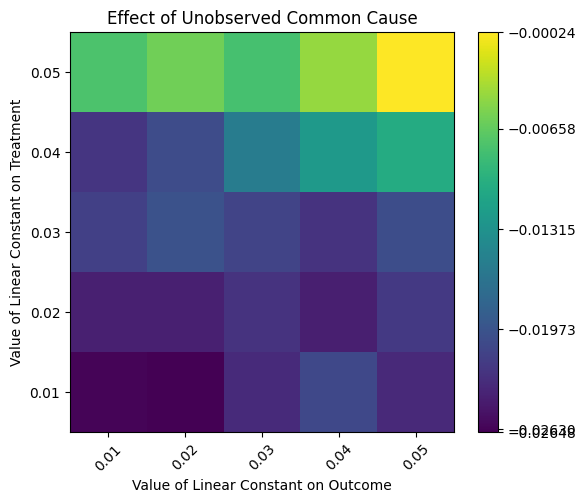

Refute: Add an Unobserved Common Cause
Estimated effect:-0.02630230701949271
New effect:(np.float64(-0.026478953329087895), np.float64(-0.00023806102081744274))



In [19]:
sensitivity_refute = model.refute_estimate(
    identified_estimand,
    estimate,
    method_name="add_unobserved_common_cause",
    confounders_effect_on_treatment="binary_flip",
    confounders_effect_on_outcome="linear",
    effect_strength_on_treatment=[0.01, 0.02, 0.03, 0.04, 0.05],
    effect_strength_on_outcome=[0.01, 0.02, 0.03, 0.04, 0.05],
)
print(sensitivity_refute)